# Trading Game #2
Anchor (Copper HG=F) vs Most Cointegrated Equity

Methodology:
- Engle-Granger cointegration selection
- Dynamic lookback optimization
- Volatility filter
- Adaptive trailing stop
- Out-of-sample performance evaluation


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.stattools import coint


In [20]:
df_prices = pd.read_csv("copper_project_data.csv", index_col="Date", parse_dates=True).sort_index()
df_prices = df_prices.replace([np.inf, -np.inf], np.nan).ffill().dropna(how="all")

print("Shape:", df_prices.shape)
print("First columns:", list(df_prices.columns)[:10])
df_prices.head()


Shape: (1538, 20)
First columns: ['AAUKF', 'ANFGF', 'BHP', 'CPER', 'ERO', 'FCX', 'FM.TO', 'GLNCY', 'HBM', 'HG=F']


,AAUKF,ANFGF,BHP,CPER,ERO,FCX,FM.TO,GLNCY,HBM,HG=F,IVPAF,JJCTF,LUNMF,PICK,RIO,SCCO,TECK,TGB,XME,ZIJMF
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,22.285599,10.097196,33.608604,17.700001,18.219,12.277882,13.098378,4.980355,4.055379,2.8330,3.250,31.049999,4.987919,23.202570,36.989109,32.032730,16.169809,0.53,27.384295,0.456822
2020-01-03,21.540184,10.097196,33.382187,17.450001,18.219,11.905825,12.260003,4.925018,3.838831,2.7985,3.130,30.600000,4.888492,22.839064,36.340614,31.162724,15.616682,0.52,27.140129,0.456822
2020-01-06,21.494074,10.097196,33.345470,17.469999,16.722,11.952329,12.230413,4.877586,3.691183,2.8005,3.070,30.490000,4.871921,22.723053,36.099743,31.215227,15.404648,0.52,26.886574,0.448037
2020-01-07,21.763039,10.047045,33.345470,17.520000,16.600,12.138360,12.782755,4.861775,3.809301,2.8040,3.077,30.610001,4.954777,22.761721,36.062687,31.260227,15.395432,0.53,27.018047,0.456822
2020-01-08,21.924419,10.047045,33.510693,17.590000,16.643,12.259279,12.260003,4.917112,3.710870,2.8190,2.960,30.799999,4.847064,22.978277,36.377670,31.440231,14.860739,0.54,26.567276,0.456822


In [21]:
def winsorize_series(x, lower_q=0.001, upper_q=0.999):
    lo, hi = x.quantile(lower_q), x.quantile(upper_q)
    return x.clip(lo, hi)

rets = df_prices.pct_change().dropna()
rets_clean = rets.apply(winsorize_series)

# Option: reconstruire des prix "clean"
df_prices_clean = (1 + rets_clean).cumprod()
df_prices_clean = df_prices_clean.multiply(df_prices.iloc[0], axis=1)

print("Returns shape:", rets_clean.shape)


Returns shape: (1537, 20)


In [22]:
ANCHOR = "HG=F"
assert ANCHOR in df_prices.columns, "Anchor HG=F introuvable dans le dataset."

prices = df_prices_clean.copy()  # on utilise les prix reconstruits (plus propre)
candidates = [c for c in prices.columns if c != ANCHOR]

print("Nb assets:", prices.shape[1])
print("Nb candidates:", len(candidates))


Nb assets: 20
Nb candidates: 19


In [23]:
def eg_coint_pvalue(y, x):
    y_log = np.log(y).dropna()
    x_log = np.log(x).dropna()
    common = y_log.index.intersection(x_log.index)
    if len(common) < 500:
        return np.nan
    _, pvalue, _ = coint(y_log.loc[common], x_log.loc[common])
    return pvalue

pvals = {col: eg_coint_pvalue(prices[ANCHOR], prices[col]) for col in candidates}
pvals = pd.Series(pvals).dropna().sort_values()

BEST = pvals.index[0]
print("Best cointegrated equity:", BEST, "| p-value:", float(pvals.iloc[0]))
pvals.head(10)


Best cointegrated equity: TGB | p-value: 0.0017065467635319752


TGB      0.001707
HBM      0.085245
ZIJMF    0.176299
LUNMF    0.193417
XME      0.246658
ANFGF    0.299328
RIO      0.301469
CPER     0.346847
ERO      0.467621
PICK     0.572818
dtype: float64

In [24]:
data = pd.concat([np.log(prices[ANCHOR]), np.log(prices[BEST])], axis=1).dropna()
data.columns = ["y", "x"]

split_ratio = 0.75
T_trn = int(len(data) * split_ratio)

train = data.iloc[:T_trn]
test  = data.iloc[T_trn:]

model = sm.OLS(train["y"], sm.add_constant(train["x"])).fit()
mu = model.params["const"]
gamma = model.params["x"]

print("Hedge ratio gamma:", float(gamma), "| intercept mu:", float(mu))
print(model.summary().tables[1])


Hedge ratio gamma: 0.343843346200139 | intercept mu: 1.2255732448609713
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2256      0.001    848.991      0.000       1.223       1.228
x              0.3438      0.002    139.281      0.000       0.339       0.349


In [25]:
spread = data["y"] - (mu + gamma * data["x"])
spread.name = "spread"
spread_ret = spread.diff().fillna(0)

spread.iloc[:5], spread_ret.iloc[:5]


(Date
 2020-01-03    0.028359
 2020-01-06    0.029073
 2020-01-07    0.023772
 2020-01-08    0.022680
 2020-01-09    0.026088
 Name: spread, dtype: float64,
 Date
 2020-01-03    0.000000
 2020-01-06    0.000714
 2020-01-07   -0.005301
 2020-01-08   -0.001092
 2020-01-09    0.003407
 Name: spread, dtype: float64)

In [26]:
def rolling_zscore(series, lookback):
    m = series.rolling(lookback).mean()
    s = series.rolling(lookback).std(ddof=0)
    z = (series - m) / s
    return z.replace([np.inf, -np.inf], np.nan).fillna(0)

def sharpe_annual(daily_returns, rf_daily=0.0):
    r = daily_returns - rf_daily
    std = r.std(ddof=0)
    return np.nan if std == 0 else np.sqrt(252) * r.mean() / std

def max_drawdown(equity_curve):
    peak = equity_curve.cummax()
    dd = (equity_curve - peak) / peak
    return dd.min()

def calmar_ratio(daily_returns):
    eq = (1 + daily_returns).cumprod()
    mdd = abs(max_drawdown(eq))
    ann_ret = (eq.iloc[-1] ** (252/len(eq)) - 1) if len(eq) > 0 else np.nan
    return np.nan if mdd == 0 else ann_ret / mdd


In [27]:
threshold = 0.7
tx_cost = 0.002  # 0.2% (tu peux le justifier dans le report)

spread_train = spread.iloc[:T_trn]
spread_ret_train = spread_ret.iloc[:T_trn]

lookbacks = list(range(5, min(360, len(spread_train)-10), 5))

best_lb, best_sh = None, -1e9

for lb in lookbacks:
    z = rolling_zscore(spread_train, lb)

    signal = np.where(z <= -threshold,  1,
             np.where(z >=  threshold, -1, 0))
    sig = pd.Series(signal, index=spread_train.index).shift(1).fillna(0)

    strat = spread_ret_train * sig

    # transaction cost when position changes
    trades = sig.diff().abs().fillna(0)
    strat = strat - tx_cost * trades

    sh = sharpe_annual(strat.dropna())
    if np.isfinite(sh) and sh > best_sh:
        best_sh, best_lb = sh, lb

print("Optimal lookback:", best_lb, "| Train Sharpe:", float(best_sh))


Optimal lookback: 75 | Train Sharpe: 1.7300782110968074


In [28]:
def run_game2_strategy(
    spread, spread_ret, lookback,
    threshold=0.7,
    tx_cost=0.002,
    vol_lookback=30,
    vol_threshold=1.5,
    trailing_stop_factor=0.025,
    min_holding=5,
    start_index=0
):
    z = rolling_zscore(spread, lookback)

    vol = spread_ret.rolling(vol_lookback).std(ddof=0)
    avg_vol = vol.mean()
    avg_vol = avg_vol if (avg_vol is not None and avg_vol > 0) else 1e-6

    vol_ok = (vol <= vol_threshold * avg_vol).fillna(True)

    raw = pd.Series(np.where(z <= -threshold,  1,
                    np.where(z >=  threshold, -1, 0)), index=spread.index)

    # apply volatility filter
    raw = raw.where(vol_ok, 0)

    pos = 0
    hold_days = 0
    stop_hits = 0
    highest = None
    lowest = None

    sig = pd.Series(0, index=spread.index, dtype=float)
    rets = pd.Series(0.0, index=spread.index, dtype=float)

    for i in range(max(start_index, 1), len(spread)):
        desired = int(raw.iloc[i])

        if pos != 0:
            hold_days += 1

        can_change = (pos == 0) or (hold_days >= min_holding)

        # adaptive stop depends on current vol regime
        v = vol.iloc[i]
        v = avg_vol if (pd.isna(v) or v <= 0) else v
        dyn_stop = trailing_stop_factor * max(v / avg_vol, 1)

        if pos != 0 and can_change:
            s_now = spread.iloc[i]
            if pos == 1:
                highest = s_now if highest is None else max(highest, s_now)
                if s_now < highest * (1 - dyn_stop):
                    stop_hits += 1
                    pos = 0
                    hold_days = 0
                    desired = 0
            elif pos == -1:
                lowest = s_now if lowest is None else min(lowest, s_now)
                if s_now > lowest * (1 + dyn_stop):
                    stop_hits += 1
                    pos = 0
                    hold_days = 0
                    desired = 0

        if not can_change:
            desired = pos

        if desired != pos:
            rets.iloc[i] -= tx_cost * abs(desired - pos)
            pos = desired
            hold_days = 0
            highest = spread.iloc[i] if pos == 1 else None
            lowest  = spread.iloc[i] if pos == -1 else None

        sig.iloc[i] = pos
        rets.iloc[i] += spread_ret.iloc[i] * sig.iloc[i-1]

    return {"signals": sig, "returns": rets, "zscore": z, "vol": vol, "stop_hits": stop_hits}

res = run_game2_strategy(
    spread=spread,
    spread_ret=spread_ret,
    lookback=best_lb,
    threshold=threshold,
    tx_cost=tx_cost,
    vol_lookback=30,
    vol_threshold=1.5,
    trailing_stop_factor=0.025,
    min_holding=5,
    start_index=T_trn
)

print("Stop hits:", res["stop_hits"])


Stop hits: 34


In [29]:
rets_all = res["returns"]
rets_oos = rets_all.iloc[T_trn:].copy()
eq_oos = (1 + rets_oos).cumprod()

print("===== OOS RESULTS =====")
print("OOS Sharpe:", float(sharpe_annual(rets_oos)))
print("OOS Max Drawdown:", float(max_drawdown(eq_oos)))
print("OOS Calmar:", float(calmar_ratio(rets_oos)))

eq_oos.tail()


===== OOS RESULTS =====
OOS Sharpe: 0.9296993304973133
OOS Max Drawdown: -0.19747420365645033
OOS Calmar: 0.8109763394144608


Date
2025-12-24    1.240756
2025-12-26    1.238274
2025-12-29    1.285607
2025-12-30    1.232845
2025-12-31    1.254762
dtype: float64

In [30]:
prices_oos = prices.loc[data.index[T_trn]:, [ANCHOR, BEST]].ffill()

bh_anchor = prices_oos[ANCHOR].pct_change().fillna(0)
bh_best   = prices_oos[BEST].pct_change().fillna(0)

eq_anchor = (1 + bh_anchor).cumprod()
eq_best   = (1 + bh_best).cumprod()

print("BH Anchor Sharpe:", float(sharpe_annual(bh_anchor)))
print("BH Best   Sharpe:", float(sharpe_annual(bh_best)))


BH Anchor Sharpe: 1.0326260878621105
BH Best   Sharpe: 1.2155055005722881


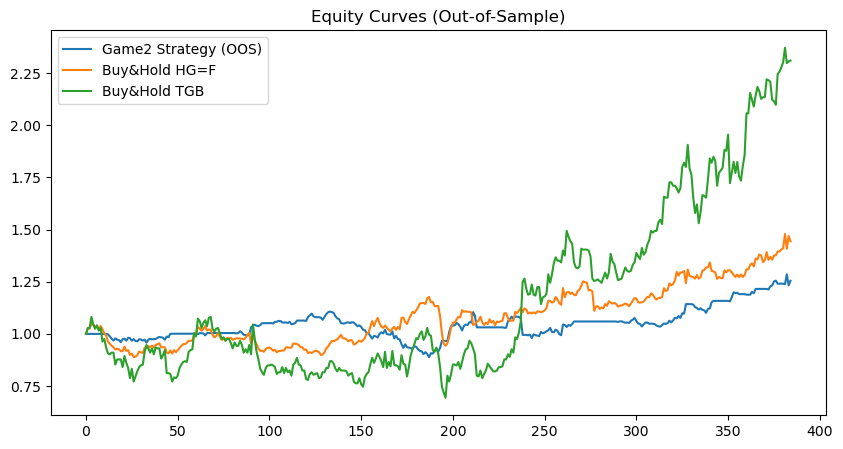

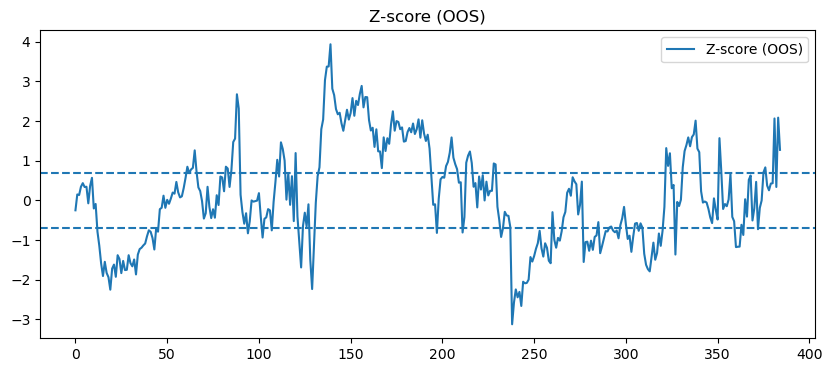

In [31]:
plt.figure(figsize=(10,5))
plt.plot(eq_oos.values, label="Game2 Strategy (OOS)")
plt.plot(eq_anchor.values, label=f"Buy&Hold {ANCHOR}")
plt.plot(eq_best.values, label=f"Buy&Hold {BEST}")
plt.title("Equity Curves (Out-of-Sample)")
plt.legend()
plt.show()

z = res["zscore"].iloc[T_trn:]
plt.figure(figsize=(10,4))
plt.plot(z.values, label="Z-score (OOS)")
plt.axhline(threshold, linestyle="--")
plt.axhline(-threshold, linestyle="--")
plt.title("Z-score (OOS)")
plt.legend()
plt.show()


In [32]:
summary = pd.DataFrame({
    "Metric": ["Sharpe (OOS)", "Max Drawdown (OOS)", "Calmar (OOS)", "Lookback*", "Threshold", "Tx cost", "Vol lookback", "Vol threshold", "Min holding", "Trailing stop factor"],
    "Value": [
        sharpe_annual(rets_oos),
        max_drawdown(eq_oos),
        calmar_ratio(rets_oos),
        best_lb,
        threshold,
        tx_cost,
        30,
        1.5,
        5,
        0.025
    ]
})
summary


,Metric,Value
0,Sharpe (OOS),0.929699
1,Max Drawdown (OOS),-0.197474
2,Calmar (OOS),0.810976
3,Lookback*,75.000000
4,Threshold,0.700000
5,Tx cost,0.002000
6,Vol lookback,30.000000
7,Vol threshold,1.500000
8,Min holding,5.000000
9,Trailing stop factor,0.025000
